Run IMSTE on MNIST, Fashion-MNIST, and Kuzushiji-MNIST. For each dataset, the gallery first shows a grid of sample images with one column per class and a configurable number of rows. The pipeline standardizes a stratified sample. By default, it divides each image into non-overlapping spatial patches, applies the same random projection to every patch, and appends a 2D sinusoidal position vector. `N_PATCHES` and `PATCH_COMPONENTS` configure the patch grid and projected dimensions per patch; `POSITION_ENCODING_SIZE` sets the positional vector length (default: equal to `PATCH_COMPONENTS`). Set `USE_PATCH_PREPROCESSOR = False` in the configuration cell to pass standardized flattened features directly to IMSTE. The summary reports the feature count passed to IMSTE and patch dimensions when enabled.

Remote datasets download on first use and are cached. Set `MAX_SAMPLES` or `N_EPOCHS` lower for a faster run. For large samples, set `GRAPH_MODE = "hierarchical"`; then `MINIBATCH_SIZE` controls MiniBatchKMeans, while `N_CLUSTERS`, `N_COARSE_MSTS`, `N_LOCAL_MSTS`, and `N_JOBS` configure graph construction. `N_MSTS` applies to exact mode.


In [19]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "notebooks" / "high_dim_mst_gallery.py").is_file()),
    None,
)
if repo_root is not None:
    sys.path.insert(0, str(repo_root / "notebooks"))
    sys.path.insert(0, str(repo_root))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Loading MNIST (28×28) ...
  10,000 samples × 784 features; 10 classes
Loading Fashion-MNIST (28×28) ...
  10,000 samples × 784 features; 10 classes
Loading Kuzushiji-MNIST (28×28) ...
  10,000 samples × 784 features; 10 classes


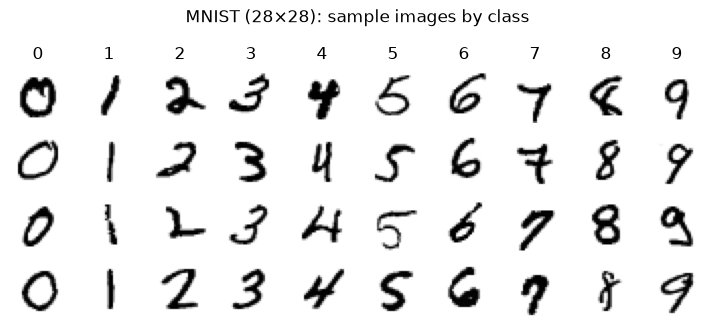

Fitting MNIST (28×28) on mps ...
  pipeline completed in 372.38 seconds
  patch preprocessing disabled; IMSTE input: 10,000 samples × 784 features


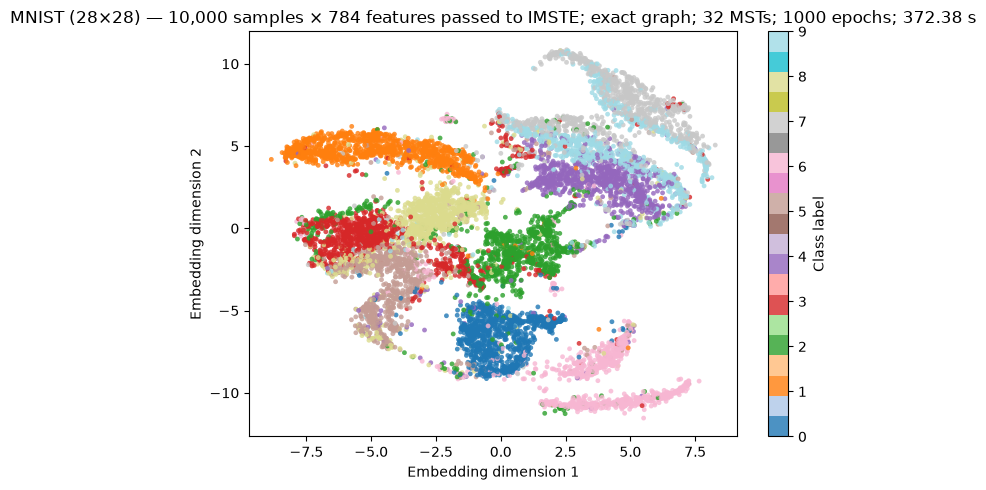

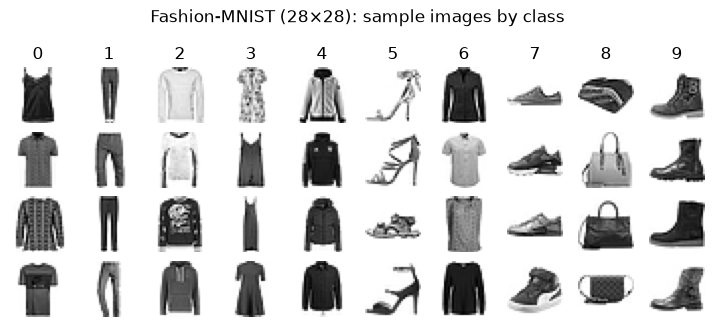

Fitting Fashion-MNIST (28×28) on mps ...
  pipeline completed in 459.92 seconds
  patch preprocessing disabled; IMSTE input: 10,000 samples × 784 features


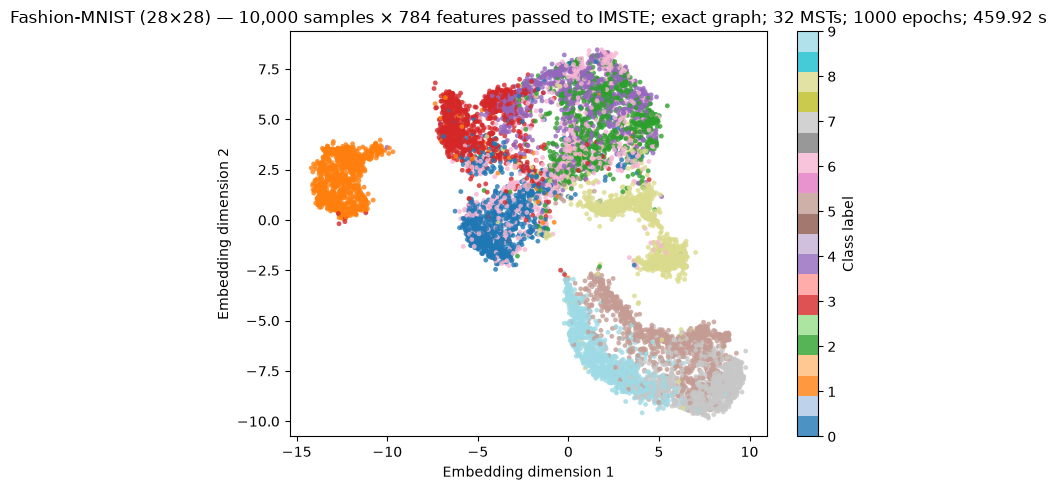

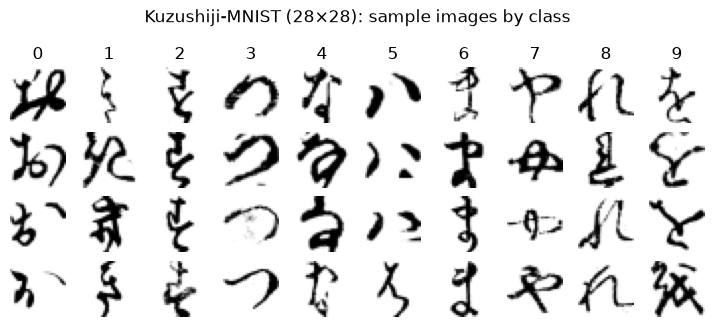

Fitting Kuzushiji-MNIST (28×28) on mps ...
  pipeline completed in 435.63 seconds
  patch preprocessing disabled; IMSTE input: 10,000 samples × 784 features


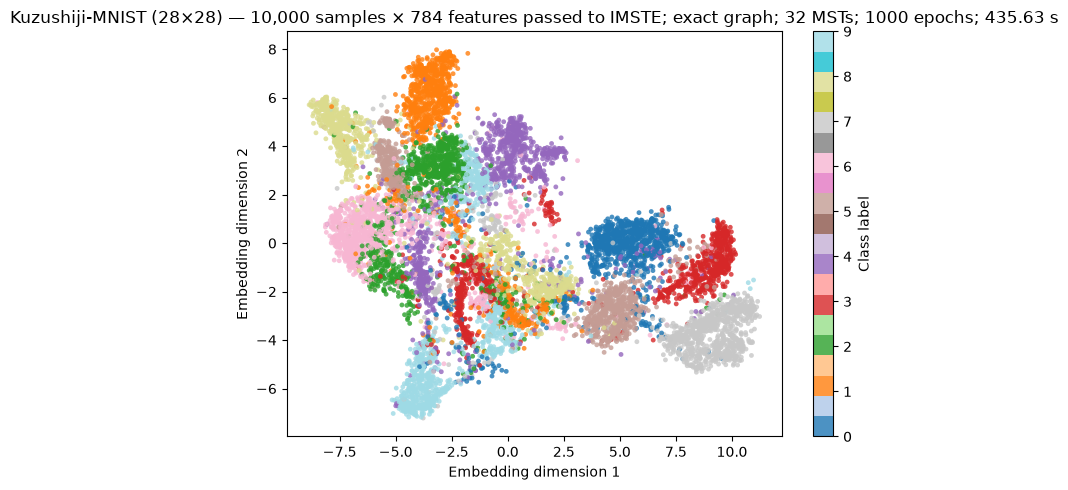

,dataset,samples,input_features,preprocessed_features,patch_grid,padded_patch_shape,patch_features,position_encoding_size,features_per_patch,classes,...,minibatch_size,n_epochs,negative_ratio,rank_weight_exponent,minkowski_p,lambda_rep,repulsion_type,unique_graph_edges,seconds,device
0,MNIST (28×28),10000,784,784,None,None,None,None,None,10,...,None,1000,5,1,2.5,0.35,bernoulli,319968,372.382121,mps
1,Fashion-MNIST (28×28),10000,784,784,None,None,None,None,None,10,...,None,1000,5,1,2.5,0.35,bernoulli,319968,459.921211,mps
2,Kuzushiji-MNIST (28×28),10000,784,784,None,None,None,None,None,10,...,None,1000,5,1,2.5,0.35,bernoulli,319968,435.633845,mps


In [20]:
from high_dim_mst_gallery import run_high_dim_mst_gallery

# Dataset
MAX_SAMPLES = 10000
SAMPLE_PLOT_ROWS = 4

#----
# Patch preprocessing
USE_PATCH_PREPROCESSOR = False
N_PATCHES = 5
PATCH_COMPONENTS = 20
POSITION_ENCODING_SIZE = None

#----
# Embedding
N_EPOCHS = 1000
NEGATIVE_RATIO = 5
RANK_WEIGHT_EXPONENT = 1
MINKOWSKI_P = 2.5
LAMBDA_REP = 0.35
REPULSION_TYPE = "bernoulli" #"bernoulli" or "inverse_distance"

#----
# Graph construction
GRAPH_MODE = "hierarchical"
N_COARSE_MSTS = 3
N_LOCAL_MSTS = 8
N_CLUSTERS = 400

GRAPH_MODE = "exact"
N_MSTS = 32

#----
# Runtime
N_JOBS = -1
MINIBATCH_SIZE = 2048

gallery = run_high_dim_mst_gallery(
    max_samples=MAX_SAMPLES,
    sample_plot_rows=SAMPLE_PLOT_ROWS,
    n_patches=N_PATCHES,
    patch_n_components=PATCH_COMPONENTS,
    position_encoding_size=POSITION_ENCODING_SIZE,
    use_patch_preprocessor=USE_PATCH_PREPROCESSOR,
    n_epochs=N_EPOCHS,
    negative_ratio=NEGATIVE_RATIO,
    rank_weight_exponent=RANK_WEIGHT_EXPONENT,
    minkowski_p=MINKOWSKI_P,
    lambda_rep=LAMBDA_REP,
    repulsion_type=REPULSION_TYPE,
    graph_mode=GRAPH_MODE,
    n_clusters=N_CLUSTERS,
    n_coarse_msts=N_COARSE_MSTS,
    n_local_msts=N_LOCAL_MSTS,
    n_msts=N_MSTS,
    n_jobs=N_JOBS,
    minibatch_size=MINIBATCH_SIZE,
)
gallery["summary"]
